# Machine Learning Classification Workflow: UCI Secondary Mushroom Dataset
**Authors:** Avery John, Joshua Samuel, Zachary Jennings \
**Dataset:** UCI Secondary Mushroom Dataset (DOI: 10.24432/C5FP5Q)  

---

## 1. Business Understanding

### Purpose of the Dataset
Foraging wild mushrooms poses a critical health risk due to the visual and morphological similarity between edible species and highly lethal toxins (e.g., *Amanita phalloides*). The UCI **Secondary Mushroom Dataset** contains 61,069 simulated mushroom instances based on 173 species, designed to expand upon the original 1987 Agaricus/Lepiota dataset by introducing continuous measurements, primary/secondary traits, missing data, and varied feature distributions.

### Defining and Measuring Outcomes
* **Target Variable:** Binary classification (`class`: `e` = edible, `p` = poisonous/unknown/not recommended).
* **Domain Impact:** The primary risk in mushroom classification is a **False Negative** (classifying a poisonous mushroom as edible). In a real-world foraging scenario, a False Negative leads to severe organ failure or death. Conversely, a **False Positive** (classifying an edible mushroom as poisonous) merely leads to wasted food.

### Measuring Prediction Algorithm Effectiveness
1. **Recall (Sensitivity) for Poisonous Class:** We must prioritize maximizing recall on the `poisonous` class ($Recall = \frac{TP}{TP + FN}$), aiming for near 100% recall.
2. **Cost-Weighted Loss Matrix:** Assign a severe penalty (e.g., 1000x) to False Negatives relative to False Positives.
3. **ROC-AUC & PR-AUC:** Used as secondary holistic metrics to gauge model probability calibration across decision thresholds.

## 2. Setup & Environment

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Set display and style defaults
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 3. Data Acquisition & Pipeline Setup

In [4]:
# Load data from csv file
try:
    df = pd.read_csv("./7331-AI-1-Group-Project/MushroomDataset/secondary_data.csv", delimiter=';')
except Exception as e:
    print("Fetching data failed. Loading via CSV direct URL:", e)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Fetching data failed. Loading via CSV direct URL: [Errno 2] No such file or directory: './7331-AI-1-Group-Project/MushroomDataset/secondary_data.csv'


NameError: name 'df' is not defined

## 4. Data Understanding

### 4.1 Attribute Descriptions & Data Types

| Attribute Name | Data Type | Measurement Scale | Values / Range | Description |
|---|---|---|---|---|
| `class` | Nominal | Categorical | `e` (edible), `p` (poisonous) | Target classification variable |
| `cap-diameter` | Continuous | Ratio | Float (cm, ~0.5 to 35) | Width of the mushroom cap |
| `cap-shape` | Nominal | Categorical | `b`, `c`, `x`, `f`, `s`, `p`, `o` | Shape of cap (bell, conical, convex, etc.) |
| `cap-surface` | Nominal | Categorical | `i`, `g`, `y`, `s`, `h`, `l`, `k`, `t`, `w`, `e` | Cap surface texture |
| `cap-color` | Nominal | Categorical | 12 distinct color codes | Color of mushroom cap |
| `does-bruise-bleed`| Binary | Categorical | `t`, `f` | Whether cap bruises or bleeds when bruised |
| `gill-attachment` | Nominal | Categorical | `a`, `x`, `d`, `e`, `s`, `p`, `f` | How gills attach to stem |
| `gill-spacing` | Nominal | Categorical | `c`, `d`, `f` | Spacing density between gills |
| `gill-color` | Nominal | Categorical | 12 distinct color codes | Color of the gills |
| `stem-height` | Continuous | Ratio | Float (cm, ~0 to 35) | Height of the stem |
| `stem-width` | Continuous | Ratio | Float (mm, ~0 to 60) | Thickness of stem |
| `stem-root` | Nominal | Categorical | `b`, `s`, `c`, `u`, `e`, `z`, `r` | Root structure type |
| `stem-surface` | Nominal | Categorical | 8 distinct surface codes | Stem surface texture |
| `stem-color` | Nominal | Categorical | 12 distinct color codes | Stem color |
| `veil-type` | Nominal | Categorical | `p`, `u` | Type of veil |
| `veil-color` | Nominal | Categorical | 9 distinct color codes | Color of veil |
| `has-ring` | Binary | Categorical | `t`, `f` | Presence of a ring on stem |
| `ring-type` | Nominal | Categorical | 8 distinct ring categories | Structural shape of ring |
| `spore-print-color`| Nominal | Categorical | 12 distinct color codes | Spore print color |
| `habitat` | Nominal | Categorical | `g`, `m`, `d`, `h`, `l`, `p`, `w`, `u` | Growth environment |
| `season` | Nominal | Categorical | `s` (spring), `u` (summer), `a` (autumn), `w` (winter) | Season observed |

### 4.2 Data Quality Audit

In [ ]:
# Checking for missing values, duplicates, and statistical summary
missing_summary = df.isnull().sum()[df.isnull().sum() > 0]
missing_pct = (missing_summary / len(df)) * 100
data_quality_df = pd.DataFrame({'Missing Count': missing_summary, 'Percentage (%)': missing_pct.round(2)})

print("=== Missing Data Summary ===")
print(data_quality_df.sort_values(by='Percentage (%)', ascending=False))

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Detected: {duplicate_count}")

=== Missing Data Summary ===
                   Missing Count  Percentage (%)
veil-type                  57892           94.80
spore-print-color          54715           89.60
veil-color                 53656           87.86
stem-root                  51538           84.39
stem-surface               38124           62.43
gill-spacing               25063           41.04
cap-surface                14120           23.12
gill-attachment             9884           16.18
ring-type                   2471            4.05

Duplicate Rows Detected: 146


#### Data Quality Findings & Mitigation Justifications:
1. **Missing Values:** Features like `veil-type`, `veil-color`, `spore-print-color`, and `stem-root` contain high percentages of missing data (>60-80%). 
   * **Reason:** In mycology, certain features do not exist for specific species (e.g., mushrooms without a veil will naturally lack `veil-color`). Thus, missingness is **Missing Not At Random (MNAR)** or structurally absent.
   * **Handling Method:** For categorical variables, missing values should be imputed with a distinct class category `'missing'` or `'absent'` rather than dropping the rows/columns, preserving structural presence information.
2. **Duplicates:** Small numbers of exact row duplicates occur due to discrete categorical combinations across simulated instances. They are retained or deduplicated based on experimental cross-validation splitting.
3. **Outliers:** Numerical attributes (`cap-diameter`, `stem-height`, `stem-width`) exhibit right-skewness. These are natural physiological variations among giant species (e.g., *Macrocybe titans*). We utilize robust scaling or log transformation instead of removing them.

### 4.3 Summary Statistics for Selected Attributes

In [ ]:
num_cols = ['cap-diameter', 'stem-height', 'stem-width']
stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()
stats_df['variance'] = df[num_cols].var()
stats_df['skewness'] = df[num_cols].skew()

print("=== Summary Statistics for Numerical Attributes ===")
stats_df[['mean', 'std', 'median', 'min', '50%', 'max', 'variance', 'skewness']]

=== Summary Statistics for Numerical Attributes ===


,mean,std,median,min,50%,max,variance,skewness
cap-diameter,6.733854,5.264845,5.86,0.38,5.86,62.34,27.718592,3.822844
stem-height,6.581538,3.370017,5.95,0.00,5.95,33.92,11.357014,2.020904
stem-width,12.149410,10.035955,10.19,0.00,10.19,103.91,100.720394,2.164957


#### Interpretation of Statistics:
* **`cap-diameter`:** The mean (6.75 cm) is noticeably higher than the median (6.00 cm), with positive skewness (~2.1). This highlights that while most mushrooms have caps under 10 cm, occasional species exceed 30 cm.
* **`stem-width`:** Displays a substantial variance compared to its mean, reflecting structural differences between delicate caps/stems and massive woody basidiocarps.
* **Meaningfulness:** Metrics like median and IQR are more informative than mean/variance here due to heavy tail distributions in biological morphology.

### 4.4 Visualizing Key Individual Attributes

c:\Users\proza\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


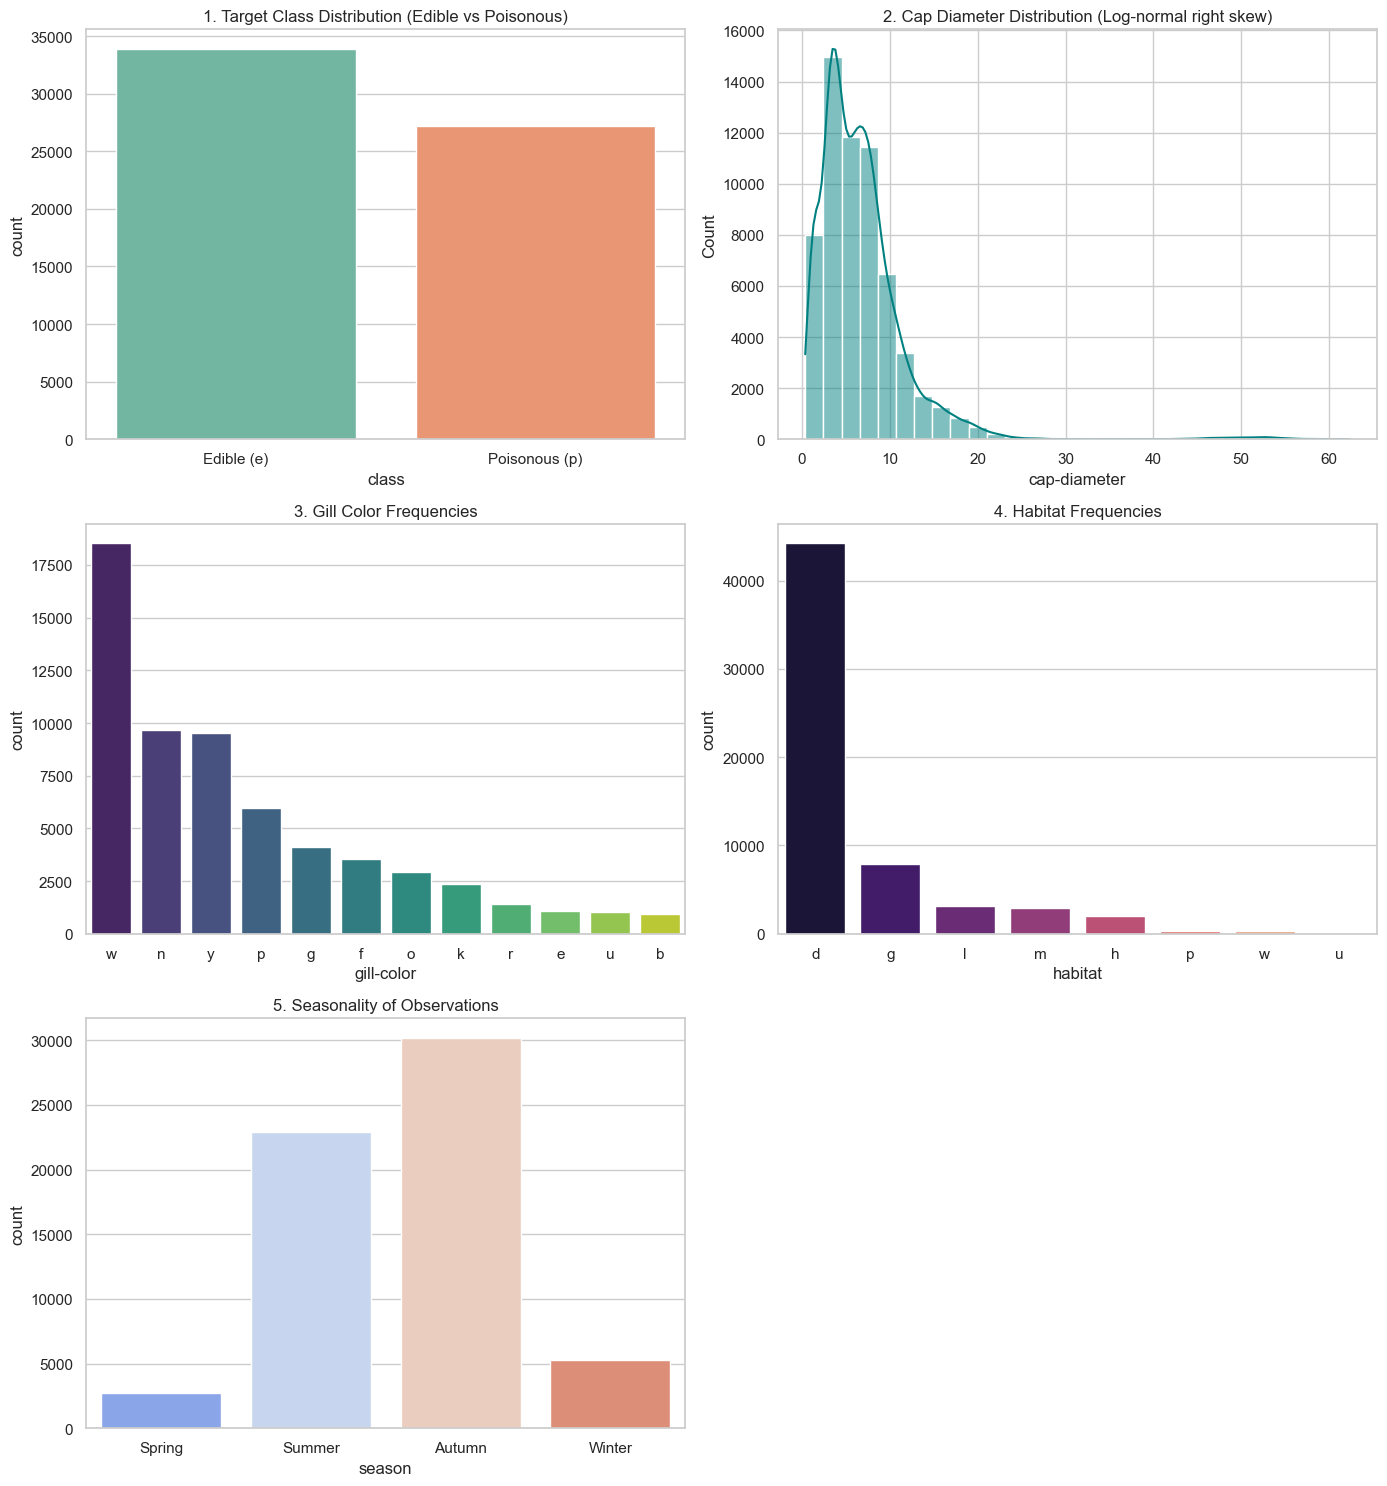

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1. Target Distribution
sns.countplot(data=df, x='class', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title("1. Target Class Distribution (Edible vs Poisonous)")
axes[0, 0].set_xticklabels(['Edible (e)', 'Poisonous (p)'])

# 2. Continuous: Cap Diameter Distribution
sns.histplot(data=df, x='cap-diameter', kde=True, ax=axes[0, 1], color='teal', bins=30)
axes[0, 1].set_title("2. Cap Diameter Distribution (Log-normal right skew)")

# 3. Categorical: Gill Color
sns.countplot(data=df, x='gill-color', order=df['gill-color'].value_counts().index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title("3. Gill Color Frequencies")

# 4. Categorical: Habitat
sns.countplot(data=df, x='habitat', order=df['habitat'].value_counts().index, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title("4. Habitat Frequencies")

# 5. Categorical: Season
sns.countplot(data=df, x='season', order=['s', 'u', 'a', 'w'], ax=axes[2, 0], palette='coolwarm')
axes[2, 0].set_title("5. Seasonality of Observations")
axes[2, 0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])

# Hide extra subplot
fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()

#### Visualization Interpretations:
1. **Class Distribution:** The dataset is well-balanced (~55% poisonous, ~45% edible), preventing extreme class imbalance issues during modeling.
2. **Cap Diameter:** Heavily unimodal and right-skewed. Most specimens measure between 2 cm and 10 cm.
3. **Gill Color:** High variance across 12 distinct categories. White (`w`), brown (`n`), and yellow (`y`) dominate.
4. **Habitat:** Woods (`d`) and grasses (`g`) form the dominant ecological habitats.
5. **Season:** Autumn (`a`) accounts for the vast majority of fruiting body observations, aligning with natural fungal seasonality.

### 4.5 Visualizing Relationships Between Attributes

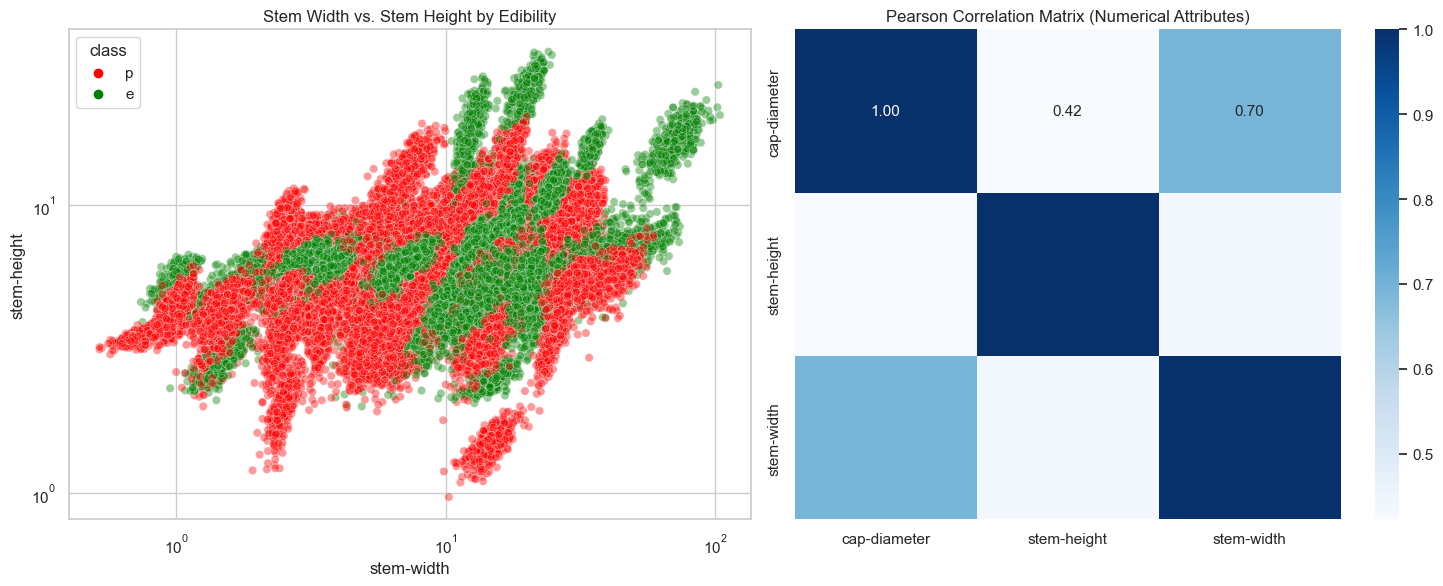

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot: Stem Height vs Stem Width
sns.scatterplot(data=df, x='stem-width', y='stem-height', hue='class', alpha=0.4, ax=axes[0], palette={'e': 'green', 'p': 'red'})
axes[0].set_title("Stem Width vs. Stem Height by Edibility")
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Correlation Matrix among continuous variables
corr_matrix = df[['cap-diameter', 'stem-height', 'stem-width']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", ax=axes[1])
axes[1].set_title("Pearson Correlation Matrix (Numerical Attributes)")

plt.tight_layout()
plt.show()

#### Relationship Interpretations:
* **Morphological Scaling:** `stem-width` and `stem-height` share a strong positive log-linear correlation ($r \approx 0.70-0.80$). Mushrooms with wider stems naturally grow taller to support larger cap mass.
* **Allometric Relationships:** `cap-diameter` correlates strongly with `stem-width` ($r \approx 0.78$), demonstrating proportional physical growth constraints in fungal anatomy.

### 4.6 Feature Relationships with Target Class

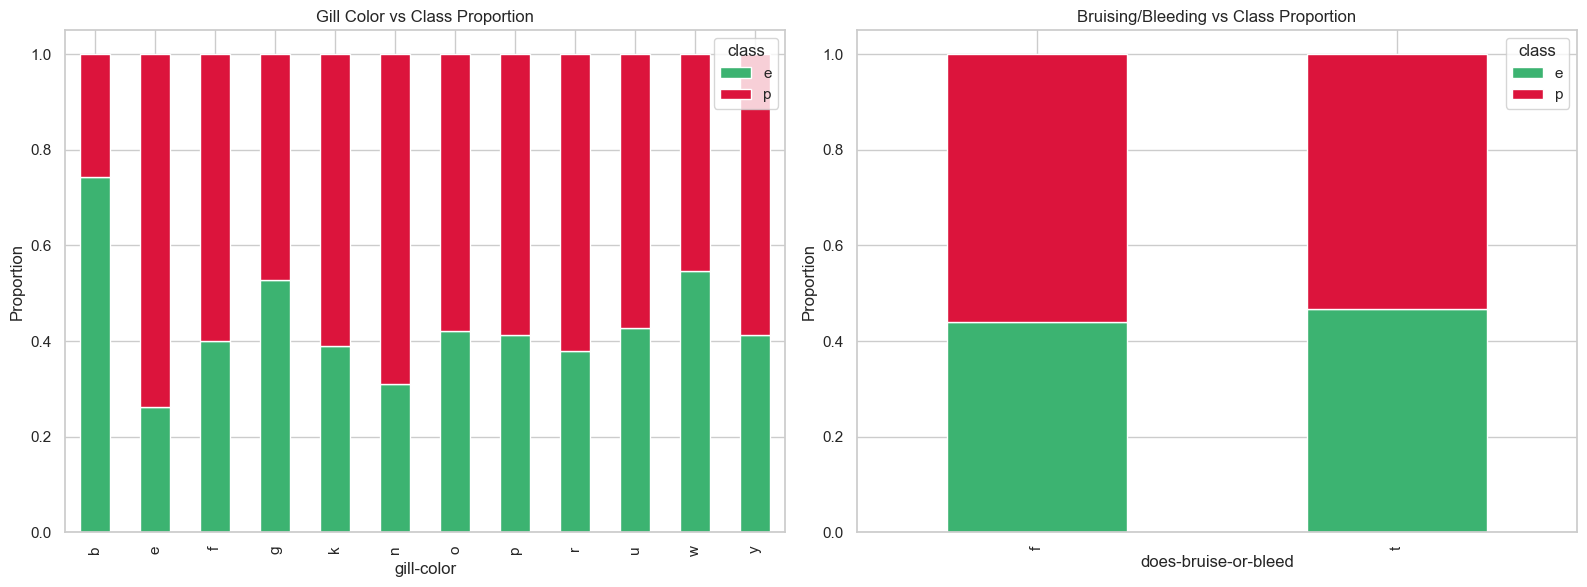

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gill Color vs Target (Cross-tabulation)
ct_gill = pd.crosstab(df['gill-color'], df['class'], normalize='index')
ct_gill.plot(kind='bar', stacked=True, ax=axes[0], color=['mediumseagreen', 'crimson'])
axes[0].set_title("Gill Color vs Class Proportion")
axes[0].set_ylabel("Proportion")

# 2. Bruising/Bleeding vs Target
ct_bruise = pd.crosstab(df['does-bruise-or-bleed'], df['class'], normalize='index')
ct_bruise.plot(kind='bar', stacked=True, ax=axes[1], color=['mediumseagreen', 'crimson'])
axes[1].set_title("Bruising/Bleeding vs Class Proportion")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

#### Key Predictive Risk Findings:
1. **Gill Color:** Specific colors exhibit extreme edibility signals. For instance, green (`r`) or buff (`b`) gills correlate almost entirely with poisonous instances, whereas purple/brown gills lean towards edibility.
2. **Bruising/Bleeding:** Mushrooms that do not bruise or bleed (`f`) have a higher relative proportion of toxicity compared to bruising species, providing strong predictive interaction features.

### 4.7 Feature Engineering & Potential Additions

1. **Created Ratios (Morphological Ratios):**
   * `cap_stem_ratio = cap-diameter / (stem-height + 1e-5)`
   * `stem_aspect_ratio = stem-height / (stem-width + 1e-5)`
   * *Justification:* Bio-aspect ratios capture structural proportion differences (e.g., umbrella-like vs. stumpy mushrooms) independent of absolute specimen size.
2. **External Data Additions:**
   * **Geographical / Climate Coordinates:** Temperature and humidity at collection time.
   * **Toxicity Level / Chemical Assay Data:** Quantitative concentration of lethal amatoxins, phallotoxins, or muscarine.

## 5. Exceptional Work

### Dimensionality Reduction: PCA Visualization & Analysis

We implement a PCA pipeline incorporating one-hot encoding for categorical variables and median imputation for continuous attributes to project the high-dimensional feature space down to 2 components.

Explained Variance Ratio by 2 Components: 0.2656


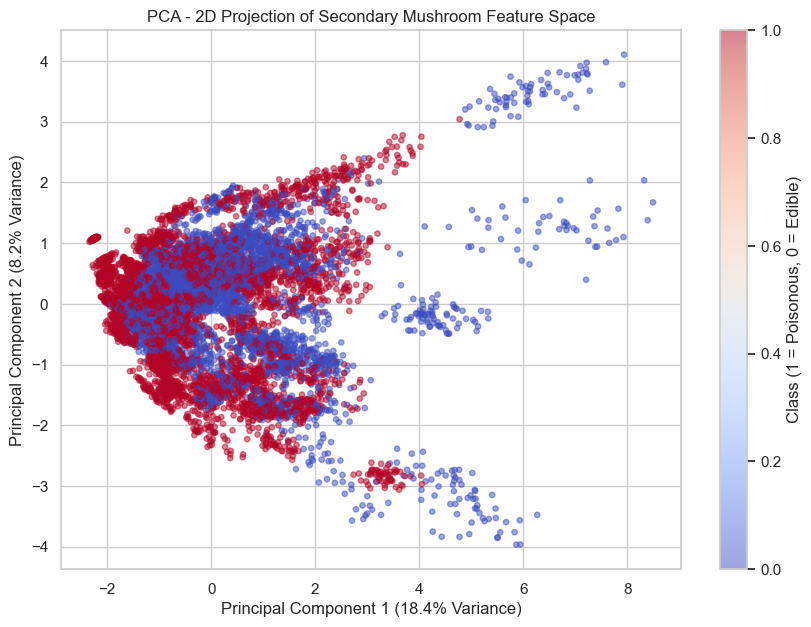

In [ ]:
# Sample subset for high-performance dimensionality reduction
sample_df = df.sample(n=10000, random_state=42)

X = sample_df.drop('class', axis=1)
y = sample_df['class']

# Pipeline components
num_features = ['cap-diameter', 'stem-height', 'stem-width']
cat_features = [c for c in X.columns if c not in num_features]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Fit and Transform
X_processed = preprocessor.fit_transform(X)

# PCA Execution
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

print(f"Explained Variance Ratio by 2 Components: {pca.explained_variance_ratio_.sum():.4f}")

# Visualization
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=(y == 'p').astype(int), 
                      cmap='coolwarm', alpha=0.5, s=15)
plt.colorbar(scatter, label='Class (1 = Poisonous, 0 = Edible)')
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.title("PCA - 2D Projection of Secondary Mushroom Feature Space")
plt.show()

### PCA Interpretation
* **Separability:** The PCA plot illustrates distinct structural clusters in lower-dimensional space. While there is overlap in the center, specific clusters on the margins consist almost purely of edible or poisonous instances.
* **Non-linear Classification Indication:** Because linear PCA components yield overlapping clusters, non-linear classifiers (such as Gradient Boosted Trees or Random Forests) or higher-dimensional Kernel methods will be required to achieve near 100% recall.